# 25SC2107E – Machine Learning (Skilling)
## Skilling Experiment: Heart Disease — XGBoost, LightGBM and SHAP Interpretability
**Dataset:** Heart Disease (Cleveland) | **Course Outcome:** CO3 | **Environment:** VS Code

In [ ]:
# Cell 1 — Import the libraries
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier,
                              AdaBoostClassifier,
                              GradientBoostingClassifier)
from sklearn.metrics import accuracy_score, log_loss
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap


In [ ]:
# Cell 2 — Load the data and split it
heart = pd.read_csv("heart.csv")
X = heart.drop(columns="target")
y = heart["target"].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(X_train.shape, X_val.shape, X_test.shape)


(212, 13) (45, 13) (46, 13)


In [ ]:
# Cell 3 — AdaBoost: how the weights move
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200, learning_rate=0.5, random_state=42)
ada.fit(X_train, y_train)
print("AdaBoost val %.4f" % accuracy_score(y_val, ada.predict(X_val)))
print("first 5 tree weights :", np.round(ada.estimator_weights_[:5], 4))
print("last 5 tree weights :", np.round(ada.estimator_weights_[-5:], 4))
print("first 5 tree errors :", np.round(ada.estimator_errors_[:5], 4))

# do three rounds by hand to see the sample weights change
w = np.ones(len(X_train)) / len(X_train)
for r in range(3):
    stump = DecisionTreeClassifier(max_depth=1, random_state=42)
    stump.fit(X_train, y_train, sample_weight=w)
    wrong = stump.predict(X_train) != y_train.values
    err = w[wrong].sum()
    alpha = 0.5 * np.log((1 - err) / err)
    print("round %d wrong %3d err %.4f alpha %.4f largest weight %.5f"
          % (r + 1, wrong.sum(), err, alpha, w.max()))
    w = w * np.exp(alpha * np.where(wrong, 1, -1))
    w = w / w.sum()


AdaBoost val 0.7778
first 5 tree weights : [0.6417 0.5668 0.4756 0.3763 0.354 ]
last 5 tree weights : [0.0111 0.0147 0.0127 0.0136 0.0133]
first 5 tree errors : [0.217  0.2435 0.2787 0.3202 0.3301]
round 1 wrong  46 err 0.2170 alpha 0.6417 largest weight 0.00472
round 2 wrong  50 err 0.2528 alpha 0.5420 largest weight 0.01087
round 3 wrong  55 err 0.3003 alpha 0.4230 largest weight 0.02150


lowest validation loss 0.4194 at tree 49


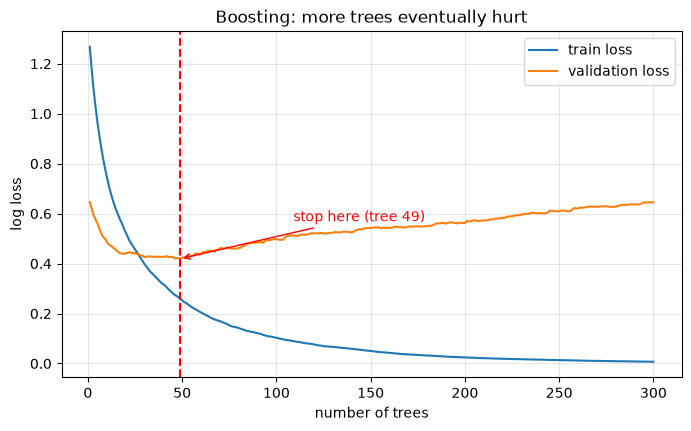

In [ ]:
# Cell 4 — Gradient boosting: the loss curve
gbc = GradientBoostingClassifier(n_estimators=300, learning_rate=0.1,
                                 max_depth=3, random_state=42)
gbc.fit(X_train, y_train)

train_loss = gbc.train_score_
val_loss = np.array([log_loss(y_val, p[:, 1], labels=[0, 1])
                     for p in gbc.staged_predict_proba(X_val)])
best_iter = int(np.argmin(val_loss)) + 1
print("lowest validation loss %.4f at tree %d" % (val_loss.min(), best_iter))

plt.figure(figsize=(8, 4.5))
plt.plot(range(1, 301), train_loss, label="train loss")
plt.plot(range(1, 301), val_loss, label="validation loss")
plt.axvline(best_iter, color="red", linestyle="--")
plt.annotate("stop here (tree %d)" % best_iter,
             xy=(best_iter, val_loss.min()),
             xytext=(best_iter + 60, val_loss.min() + 0.15),
             arrowprops=dict(arrowstyle="->", color="red"), color="red")
plt.xlabel("number of trees")
plt.ylabel("log loss")
plt.title("Boosting: more trees eventually hurt")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


best_iteration: 97
best_score    : 0.4218
XGBoost val 0.8000


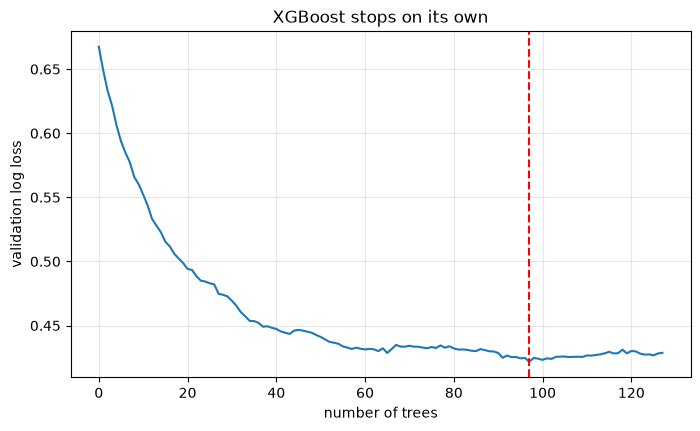

In [ ]:
# Cell 5 — XGBoost: let early stopping choose the number of trees
xgb = XGBClassifier(n_estimators=1000, learning_rate=0.05, max_depth=3,
                    subsample=0.8, colsample_bytree=0.8,
                    eval_metric="logloss", early_stopping_rounds=30,
                    random_state=42)
xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

print("best_iteration:", xgb.best_iteration)
print("best_score    : %.4f" % xgb.best_score)
print("XGBoost val %.4f" % accuracy_score(y_val, xgb.predict(X_val)))

history = xgb.evals_result()["validation_0"]["logloss"]
plt.figure(figsize=(8, 4.5))
plt.plot(history)
plt.axvline(xgb.best_iteration, color="red", linestyle="--")
plt.xlabel("number of trees")
plt.ylabel("validation log loss")
plt.title("XGBoost stops on its own")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# Cell 6 — LightGBM
lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.05,
                      max_depth=3, num_leaves=8, random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)
print("LightGBM val %.4f" % accuracy_score(y_val, lgbm.predict(X_val)))


LightGBM val 0.8222


In [ ]:
# Cell 7 — Six models in one table
models = {
    "DecisionTree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=200, learning_rate=0.5, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=xgb.best_iteration,
                            learning_rate=0.05, max_depth=3, subsample=0.8,
                            colsample_bytree=0.8, eval_metric="logloss", random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=300, learning_rate=0.05,
                               max_depth=3, num_leaves=8, random_state=42, verbose=-1),
}

rows = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    rows.append({
        "model": name,
        "train_acc": round(accuracy_score(y_train, model.predict(X_train)), 4),
        "val_acc": round(accuracy_score(y_val, model.predict(X_val)), 4),
        "test_acc": round(accuracy_score(y_test, model.predict(X_test)), 4),
        "fit_time_s": round(elapsed, 3)
    })

comparison = pd.DataFrame(rows).sort_values("val_acc", ascending=False)
comparison = comparison.reset_index(drop=True)
comparison


,model,train_acc,val_acc,test_acc,fit_time_s
0,RandomForest,1.0000,0.8222,0.8043,0.684
1,LightGBM,0.9953,0.8222,0.6957,0.045
2,DecisionTree,0.9104,0.8000,0.7609,0.007
3,GradientBoosting,1.0000,0.8000,0.6739,0.101
4,XGBoost,0.9481,0.8000,0.7826,0.131
5,AdaBoost,0.9104,0.7778,0.7609,0.401


shap_values shape: (45, 13)
base value: 0.1788


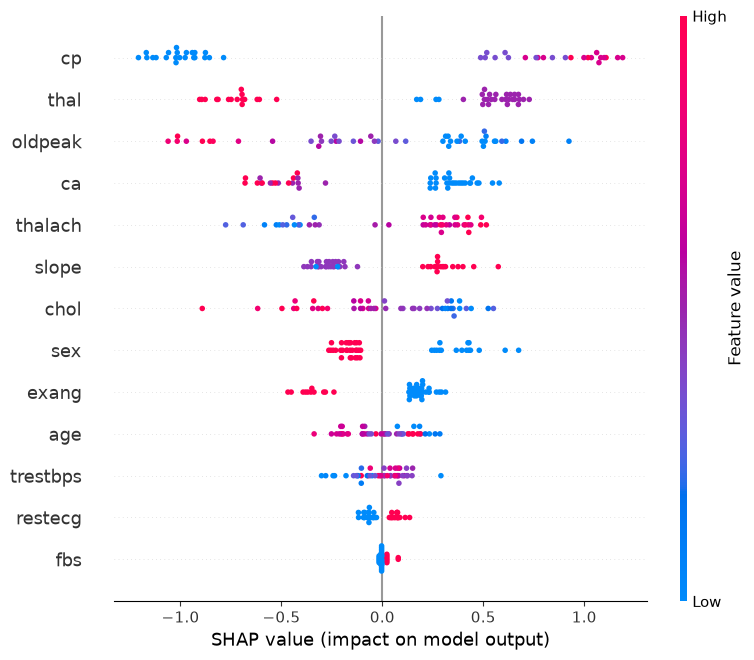

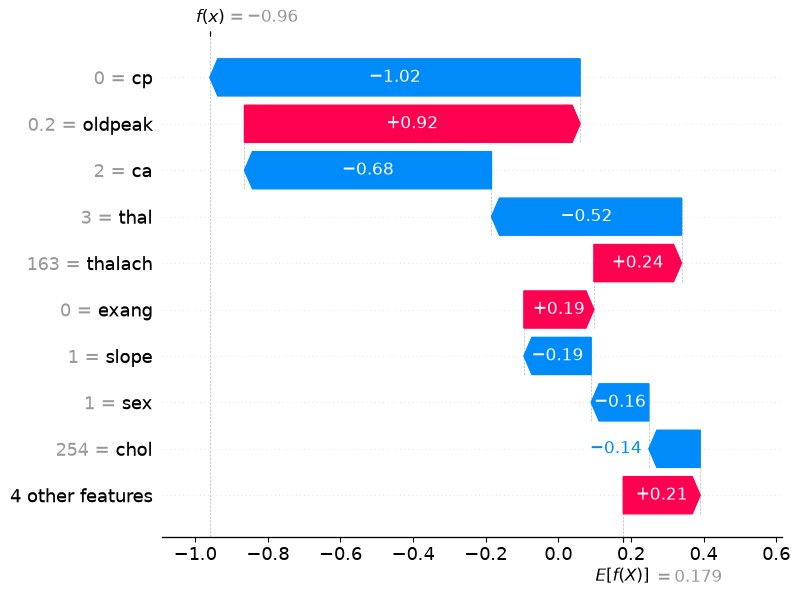

In [ ]:
# Cell 8 — SHAP: explaining the predictions
best_model = models["XGBoost"]
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_val)
print("shap_values shape:", shap_values.shape)
print("base value: %.4f" % explainer.expected_value)

shap.summary_plot(shap_values, X_val, feature_names=list(X.columns))

shap.plots.waterfall(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_val.iloc[0].values,
    feature_names=list(X.columns)))


In [ ]:
# Deliverable Function
def shap_feature_summary(model, X_val, feature_names, top_n=5):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_val)
    mean_abs = np.abs(shap_values).mean(axis=0)

    summary = pd.DataFrame({"feature": feature_names,
                            "mean_abs_shap": mean_abs})
    summary = summary.sort_values("mean_abs_shap", ascending=False)
    summary = summary.head(top_n)
    summary["mean_abs_shap"] = summary["mean_abs_shap"].round(4)
    return summary.reset_index(drop=True)


top5 = shap_feature_summary(best_model, X_val, list(X.columns), top_n=5)
top5


,feature,mean_abs_shap
0,cp,0.9323
1,thal,0.6092
2,oldpeak,0.4672
3,ca,0.4216
4,thalach,0.3696
